# Lab 2: One-Dimensional Signals & the Fourier Transform

**Signal, Image and Video Processing**

### What we'll do

| Part | Topic | Level |
|------|-------|-------|
| 1 | Build and listen to simple signals | 🟢 Basic |
| 2 | See what the FFT reveals about a signal | 🟢 Basic |
| 3 | Spectrograms: frequency over time | 🟢 Basic |
| 4 | Filter by masking in the frequency domain | 🟡 Intermediate |
| 5 | Practical filters (Butterworth) and audio | 🟡 Intermediate |
| 6 | Analyse a real ECG heart signal | 🟡 Intermediate |
| 7 | Audio features for ML (Mel spectrograms & MFCCs) | 🔴 Advanced |

### How to use this notebook

- **Read the markdown cells** before running the code — they explain *why* we do each step.
- **Run each code cell** and look at the output before moving on.
- Look for 🧪 **Experiment** boxes — these suggest things to change and re-run. Try them!
- The code is intentionally short. If something is unclear, re-read the lecture notes.


In [35]:
# Run this cell first to load all libraries
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio, display

# Optional libraries (some parts work without them)
try:
    import librosa
    import librosa.display
    LIBROSA = True
except ImportError:
    LIBROSA = False
    print('librosa not found. Parts 1-6 will work fine. Part 7 (Mel/MFCC) will be skipped.')

try:
    import wfdb
    WFDB = True
except ImportError:
    WFDB = False
    print('wfdb not found. Part 6 will use a synthetic ECG instead.')

print('Setup complete.')


Setup complete.


---
## Part 1: Building Signals in the Time Domain 🟢

A 1D signal is just a sequence of numbers — one value per time step. To create a digital signal, we need to decide:

- **Sample rate (`sr`)**: how many samples per second. CD audio uses 44,100. We'll use 22,050 (plenty for our purposes).
- **Duration**: how long the signal lasts.
- **Frequency**: how many oscillations per second (measured in Hertz, Hz). Higher frequency = higher pitch.

The formula for a pure tone (sine wave) at frequency $f$ is:

$$y(t) = \sin(2\pi f t)$$

Let's create a pure tone at 440 Hz — this is the note A4, the standard tuning reference.

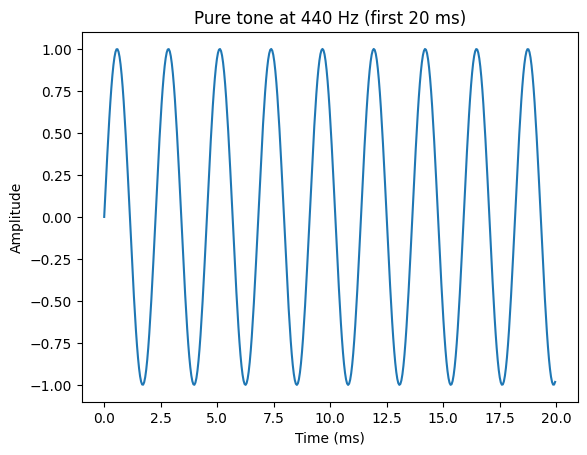

In [36]:
sr = 22050                  # sample rate (Hz)
duration = 1.0              # seconds
freq = 440                  # frequency (Hz) — the note A4

t = np.linspace(0, duration, int(sr * duration), endpoint=False)
y = np.sin(2 * np.pi * freq * t)

# Plot the first 20 milliseconds (otherwise we just see a filled block)
ms = 20
n = int(ms / 1000 * sr)
plt.plot(t[:n] * 1000, y[:n])
plt.xlabel('Time (ms)')
plt.ylabel('Amplitude')
plt.title(f'Pure tone at {freq} Hz (first {ms} ms)')
plt.show()

Audio(y, rate=sr)

🧪 **Experiment:** Change `freq` to other values and re-run:
- `261` (middle C)
- `880` (one octave above A4 — double the frequency)
- `100` (a low bass tone)
- `5000` (a high-pitched tone)

Notice how the waveform gets more compressed (more oscillations per millisecond) as frequency increases.

---

### Mixing signals

Real-world sounds are almost never a single pure tone. When you play a chord on a piano, you hear multiple frequencies at once. We can simulate this by simply **adding** sine waves together.

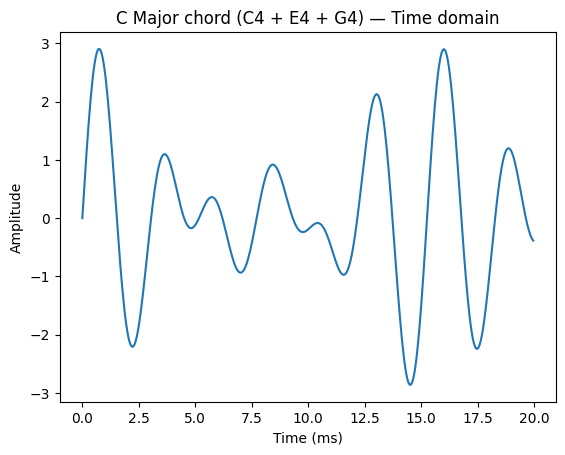

In [37]:
# A chord: three notes playing simultaneously
y_c = np.sin(2 * np.pi * 261.63 * t)   # C4
y_e = np.sin(2 * np.pi * 329.63 * t)   # E4
y_g = np.sin(2 * np.pi * 392.00 * t)   # G4

y_chord = y_c + y_e + y_g

plt.plot(t[:n] * 1000, y_chord[:n])
plt.xlabel('Time (ms)')
plt.ylabel('Amplitude')
plt.title('C Major chord (C4 + E4 + G4) — Time domain')
plt.show()

Audio(y_chord / np.max(np.abs(y_chord)), rate=sr)

The waveform looks complex and messy. Just by looking at it, can you tell that three frequencies are present? Probably not — and that's exactly the problem the Fourier Transform solves.

🧪 **Experiment:** Try making a different chord. For example, A minor uses A4 (440), C5 (523.25), and E5 (659.25).

---
## Part 2: The FFT — What Frequencies Are Present? 🟢

The **Fast Fourier Transform (FFT)** takes a time-domain signal and tells you which frequencies are present and how strong each one is. The result is called the **frequency spectrum**.

Think of it this way:
- **Time domain** answers: "what is the amplitude at each moment in time?"
- **Frequency domain** answers: "how much of each frequency is in the signal?"

From the lecture notes, each Fourier coefficient $X_k = \langle \mathbf{x}, \mathbf{w}_k \rangle$ is the **projection** of the signal onto a sinusoidal basis vector at frequency $k$. Large $|X_k|$ means the signal contains a lot of frequency $k$.

The key function is `np.fft.fft()`. It returns complex numbers — we take the absolute value to get the **magnitude** (strength) of each frequency.

Below is a helper function that computes and plots the frequency spectrum. We will reuse it throughout the lab.


### Key parameters: sampling rate, Nyquist limit, and frequency resolution

Given a signal of $N$ samples recorded over a duration $T$ seconds:

- **Sampling rate** $f_s = N / T$ (samples per second, in Hz). This notebook uses the variable name `sr` (samplig rate) for audio and `fs` (frequency of sampling) for ECG — they mean the same thing.
- **Maximum detectable frequency** (Nyquist limit): $f_s / 2$. The FFT cannot reveal anything above this — higher frequencies get folded back down (aliasing).
- **Frequency resolution**: $\Delta f = 1 / T$. This is the spacing between adjacent FFT bins. Longer recordings give finer resolution.

For example, 22050 samples over 1 second gives $f_s = 22050$ Hz, a Nyquist limit of 11025 Hz, and a resolution of 1 Hz. The `max_freq` parameter in our plotting function below simply zooms in on the range where the interesting content lives (e.g., up to 6000 Hz for speech, or 50 Hz for ECG).

In [38]:
def plot_spectrum(signal, sr, title='', ax=None, max_freq=2000):
    """Compute the FFT and plot the magnitude spectrum."""
    fft_vals  = np.fft.fft(signal)
    magnitude = np.abs(fft_vals)
    freqs     = np.fft.fftfreq(len(signal), d=1/sr)
    
    # The FFT output is symmetric for real signals — keep only positive half
    mask = (freqs >= 0) & (freqs <= max_freq)
    
    if ax is None:
        fig, ax = plt.subplots()
    ax.plot(freqs[mask], magnitude[mask], linewidth=0.8)
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Magnitude')
    ax.set_title(title)
    return ax

Let's use it on our chord signal. We should see **three peaks** — one for each note.

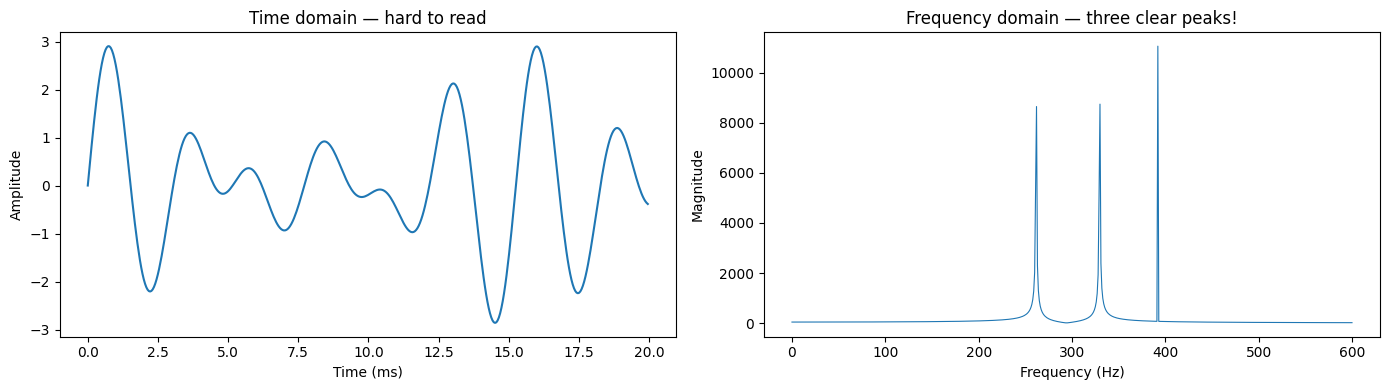

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(t[:n] * 1000, y_chord[:n])
axes[0].set_xlabel('Time (ms)')
axes[0].set_ylabel('Amplitude')
axes[0].set_title('Time domain — hard to read')

plot_spectrum(y_chord, sr, 'Frequency domain — three clear peaks!', axes[1], max_freq=600)

plt.tight_layout()
plt.show()

The three peaks correspond exactly to the three frequencies we mixed together: C4 (≈262 Hz), E4 (≈330 Hz), and G4 (≈392 Hz). The frequency domain makes the structure of the signal immediately visible.

### What happens when we add noise?

Real signals always have some noise. Let's add random noise to our chord and see how the spectrum changes.

### The Inverse FFT: going back to the time domain

The Fourier Transform is **invertible** — no information is lost. We can go to the frequency domain and come back to get the exact same signal. This is crucial: it means we can *modify* the spectrum and then reconstruct a new signal.

Let's verify the round-trip: `signal → FFT → inverse FFT → same signal`.


Maximum reconstruction error: 2.11e-15


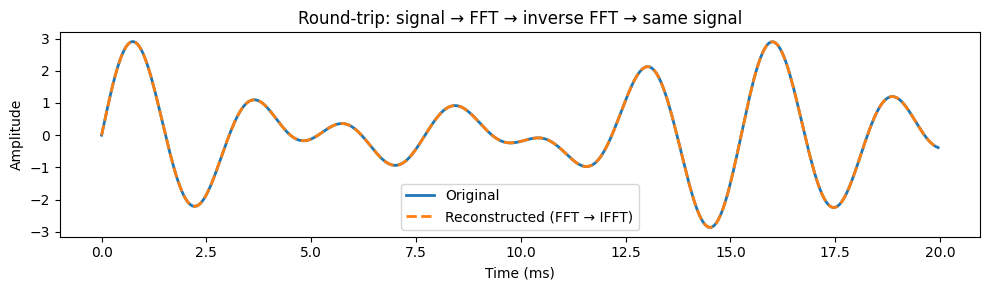

In [40]:
# Forward FFT
Y_chord = np.fft.fft(y_chord)

# Inverse FFT: go back to time domain
y_reconstructed = np.fft.ifft(Y_chord).real  # .real discards tiny imaginary rounding noise

# Check: is the reconstructed signal the same as the original?
max_error = np.max(np.abs(y_chord - y_reconstructed))
print(f'Maximum reconstruction error: {max_error:.2e}')

# Plot a small segment to see they overlap perfectly
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(t[:n]*1000, y_chord[:n], label='Original', linewidth=2)
ax.plot(t[:n]*1000, y_reconstructed[:n], '--', label='Reconstructed (FFT → IFFT)', linewidth=2)
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Amplitude')
ax.set_title('Round-trip: signal → FFT → inverse FFT → same signal')
ax.legend()
plt.tight_layout()
plt.show()


The error is essentially zero (on the order of $10^{-15}$, which is machine precision). The two curves lie exactly on top of each other.

This means that if we modify the spectrum *before* taking the inverse FFT — for instance, by zeroing out some frequencies — we get a new signal with those frequencies removed. That's the idea behind **filtering with a frequency mask**, which we'll explore in Part 4.


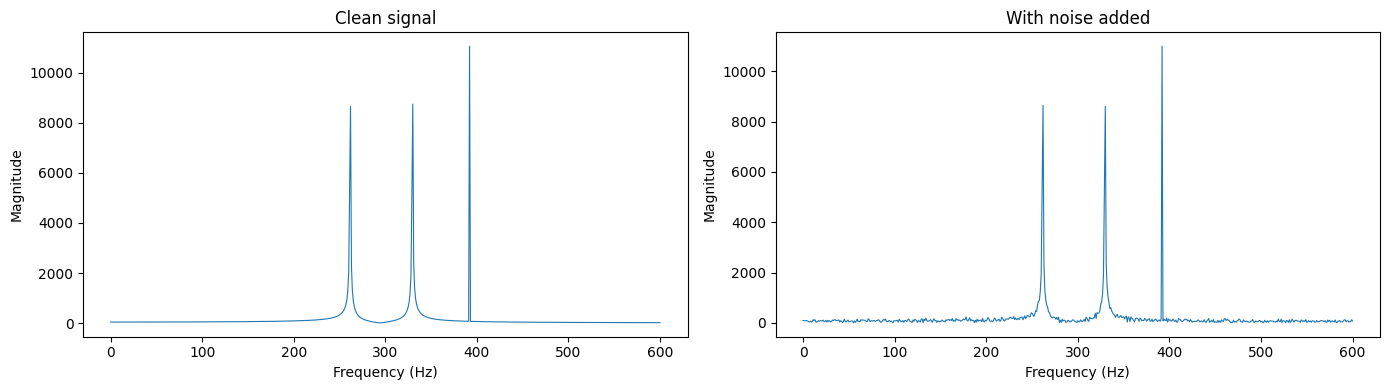

In [41]:
noise_level = 0.5
y_noisy = y_chord + noise_level * np.random.randn(len(y_chord))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_spectrum(y_chord, sr, 'Clean signal', axes[0], max_freq=600)
plot_spectrum(y_noisy, sr, 'With noise added', axes[1], max_freq=600)
plt.tight_layout()
plt.show()

Audio(y_noisy / np.max(np.abs(y_noisy)), rate=sr)

Noise raises the "floor" of the spectrum (random energy at all frequencies), but the peaks are still clearly visible. This is why frequency analysis is so powerful — it can reveal structure that is hidden in a noisy time-domain signal.

🧪 **Experiment:** Try different values for `noise_level` (e.g., 0.1, 1.0, 3.0). At what point do the peaks become hard to see? Can you still hear the chord?

---
## Part 3: Spectrograms — Frequency Over Time 🟢

The FFT tells you *which* frequencies are present, but not *when* they occur. It gives an average over the entire signal.

For example, if a song has a low note in the first half and a high note in the second half, a single FFT will show both frequencies — but won't tell you which came first.

The solution is the **spectrogram**: we chop the signal into short overlapping windows, compute the FFT of each window, and display the results as an image:
- **x-axis**: time
- **y-axis**: frequency
- **colour**: intensity (how strong that frequency is at that moment)

To demonstrate this clearly, let's create a **chirp** — a signal whose frequency sweeps upward over time.

In [42]:
# A chirp: frequency sweeps from 200 Hz to 2000 Hz over 2 seconds
dur = 2.0
t_chirp = np.linspace(0, dur, int(sr * dur), endpoint=False)
f_start, f_end = 200, 2000

# The instantaneous frequency increases linearly from f_start to f_end
phase = 2 * np.pi * (f_start * t_chirp + (f_end - f_start) / (2 * dur) * t_chirp**2)
y_chirp = np.sin(phase)

Audio(y_chirp, rate=sr)

Now let's compare: what does a single FFT tell us vs. the spectrogram?

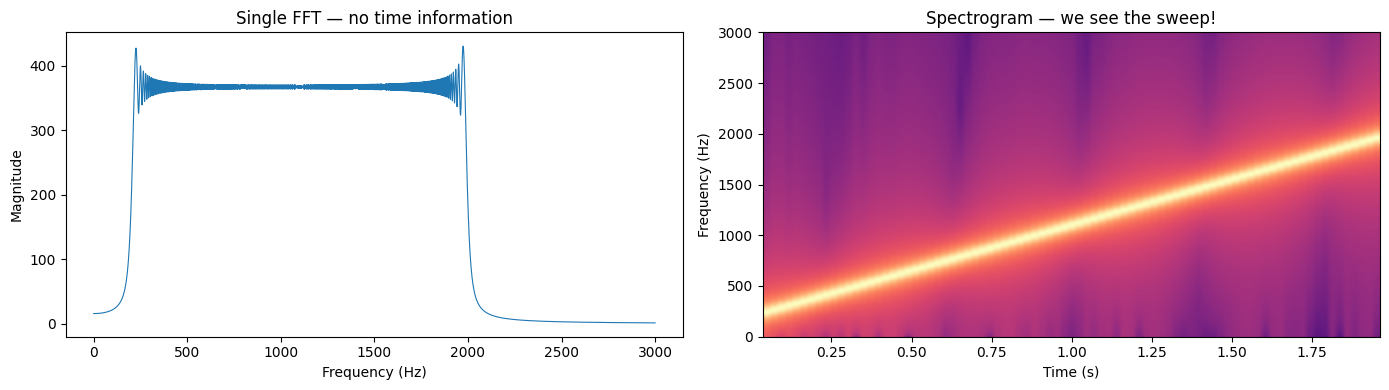

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Single FFT: we see that 200-2000 Hz are present, but no timing
plot_spectrum(y_chirp, sr, 'Single FFT — no time information', axes[0], max_freq=3000)

# Spectrogram: we see the frequency rising over time
axes[1].specgram(y_chirp, NFFT=2048, Fs=sr, noverlap=1536, cmap='magma')
axes[1].set_ylim(0, 3000)
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Frequency (Hz)')
axes[1].set_title('Spectrogram — we see the sweep!')

plt.tight_layout()
plt.show()

The spectrogram clearly shows the frequency rising from 200 Hz to 2000 Hz over the 2 seconds. The single FFT just shows a broad hump — all time information is lost.

### The time–frequency trade-off

The spectrogram has one important parameter: the **window size** (`NFFT`). This controls a fundamental trade-off:

| Window size | Frequency resolution | Time resolution |
|------------|---------------------|-----------------|
| Small (e.g., 256) | Poor (blurry peaks) | Good (precise timing) |
| Large (e.g., 8192) | Good (sharp peaks) | Poor (blurry timing) |

You **cannot** have both at once — this is a fundamental limitation, sometimes called the uncertainty principle of signal processing. Let's see this in action.

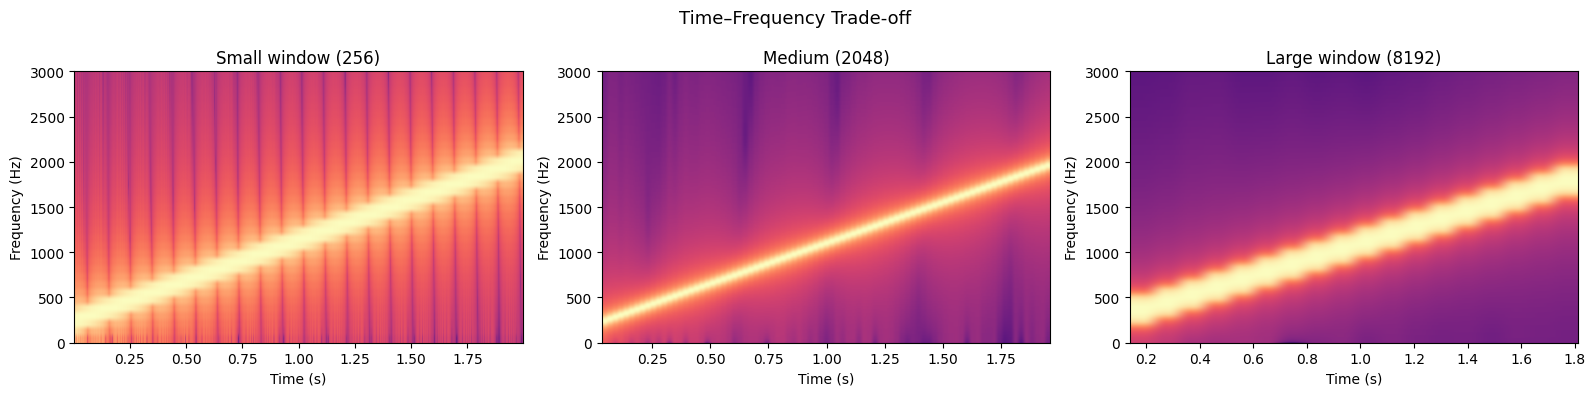

In [76]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, nfft, label in zip(axes, [256, 2048, 8192],
                            ['Small window (256)', 'Medium (2048)', 'Large window (8192)']):
    ax.specgram(y_chirp, NFFT=nfft, Fs=sr, noverlap=nfft*3//4, cmap='magma')
    ax.set_ylim(0, 3000)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Frequency (Hz)')
    ax.set_title(label)

plt.suptitle('Time–Frequency Trade-off', fontsize=13)
plt.tight_layout()
plt.show()

🧪 **Experiment:** Look at the three spectrograms:
- In the **small window** plot, the chirp line is narrow in time but thick in frequency — the 86 Hz bins can't pinpoint the exact frequency. 
- In the **large window** plot, the frequency bins are very fine (2.7 Hz), but each window spans 372 ms — during which the chirp sweeps through ~330 Hz. All those frequencies land in the same column, producing a thick vertical smear.
- The **medium window** is a compromise between the two.

Try changing the values in the list `[256, 2048, 8192]` to see how the picture changes. Can you find a window size that makes the chirp look sharpest?

### Understanding the time–frequency trade-off

The window size `NFFT` determines the fundamental resolution limits:

- **Frequency resolution** (bin height): $\Delta f = f_s / \texttt{NFFT}$
- **Time resolution** (blur): $\Delta t = \texttt{NFFT} / f_s$

Their product is always constant: $\Delta f \times \Delta t = 1$. Improving one necessarily worsens the other. This is the **uncertainty principle of signal processing**: you cannot know both *exactly when* and *exactly what frequency* at the same time.

The **overlap** (or equivalently, the **hop** = NFFT − overlap) controls how densely the windows are spaced. Each column of the spectrogram is one window's FFT, and the hop determines the spacing between columns. With 75% overlap the columns are 4× denser, making the image smoother — but the underlying blur is still set by the window size. Think of it like upscaling an image: more pixels, but no extra sharpness.

For our three spectrograms with $f_s = 22050$ Hz and 75% overlap:

- `NFFT = 256` → blur = 11.6 ms, $\Delta f$ = 86 Hz, hop = 2.9 ms (good timing, blurry frequencies)
- `NFFT = 2048` → blur = 93 ms, $\Delta f$ = 10.8 Hz, hop = 23 ms (balanced)
- `NFFT = 8192` → blur = 372 ms, $\Delta f$ = 2.7 Hz, hop = 93 ms (sharp frequencies, blurry timing)

Look at the three spectrograms above — the chirp line gets thinner in one axis but thicker in the other.

### A more musical example

Let's create a short melody — four notes played one after another — and visualise it as a spectrogram.

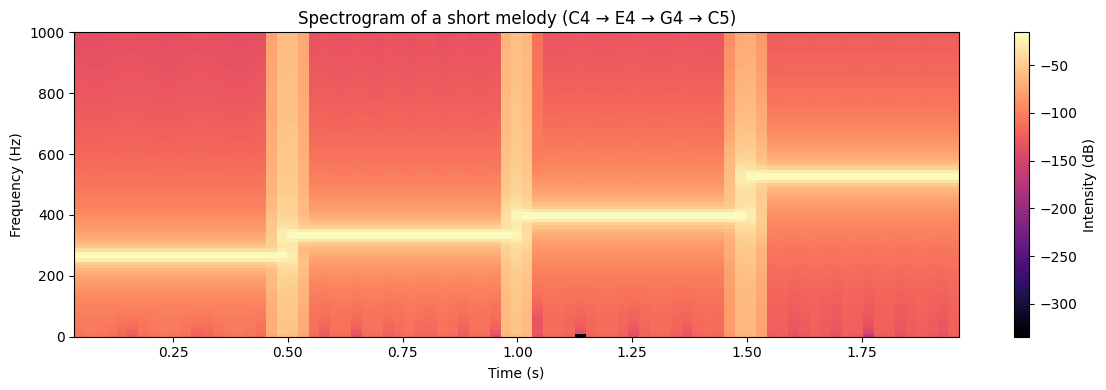

In [45]:
# Four notes, each lasting 0.5 seconds, played in sequence
notes = [261.63, 329.63, 392.00, 523.25]  # C4, E4, G4, C5
note_dur = 0.5

y_melody = np.concatenate([
    np.sin(2 * np.pi * f * np.linspace(0, note_dur, int(sr * note_dur), endpoint=False))
    for f in notes
])

plt.figure(figsize=(12, 4))
plt.specgram(y_melody, NFFT=2048, Fs=sr, noverlap=1536, cmap='magma')
plt.ylim(0, 1000)
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.colorbar(label='Intensity (dB)')
plt.title('Spectrogram of a short melody (C4 → E4 → G4 → C5)')
plt.tight_layout()
plt.show()

Audio(y_melody / np.max(np.abs(y_melody)), rate=sr)

You should see four horizontal "steps" going upward — each one is a note at a specific frequency and time. This is exactly how music visualisers and transcription software work.

🧪 **Experiment:**
- Change the `notes` list to play a descending scale instead.
- Change `note_dur` to 0.2 — the notes get shorter. Does the spectrogram still resolve them?
- Try playing two notes simultaneously (hint: add two sine waves for the same time interval).

---
## Part 4: Filtering with Frequency Masks 🟡

Now that we know the FFT is invertible, we can use a simple and intuitive approach to remove unwanted frequencies:

1. **FFT**: go to the frequency domain
2. **Mask**: multiply the spectrum by a vector of ones (keep) and zeros (remove)
3. **Inverse FFT**: go back to the time domain

This is the most transparent way to understand filtering: you literally see which frequencies you are keeping and which you are throwing away.

### Setting up a test signal

To test our filters, we'll build a speech-like signal using **formant synthesis** — this generates a vowel sound by filtering a glottal pulse train through resonances, producing something that sounds like a human voice saying "aah". We then add realistic noise on top:

- **Vowel sound** with formants at ~730, 1090, and 2440 Hz (what we want to keep)
- **Low rumble** at 30 Hz (e.g., from wind or vibrations)
- **Power-line hum** at 50 Hz (electromagnetic interference)
- **High-frequency hiss** (random electronic noise)


Clean vowel sound:


Dirty recording (vowel + rumble + hum + hiss):


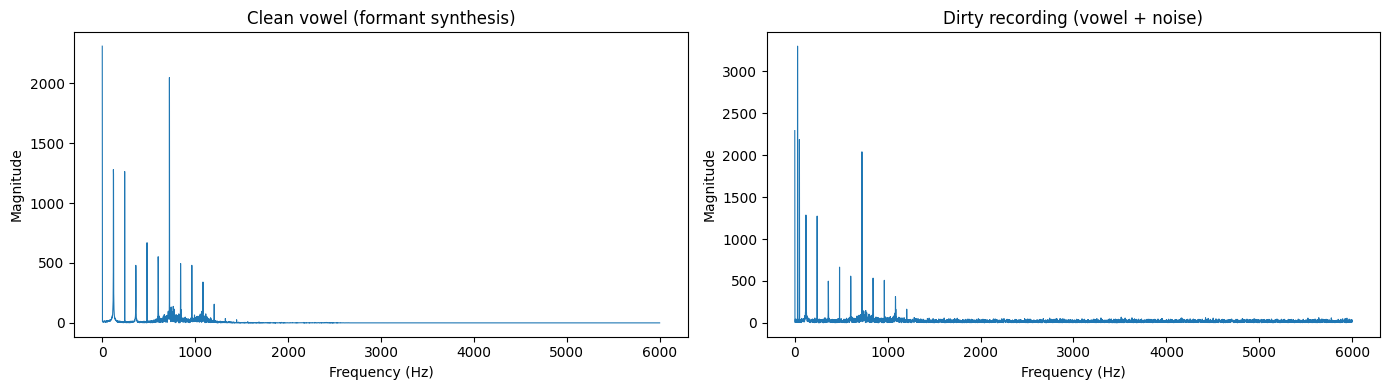

In [46]:
from scipy.signal import lfilter

np.random.seed(42)
t_f = np.linspace(0, 1.0, sr, endpoint=False)

# --- Formant synthesis: a realistic vowel sound ---
# Step 1: glottal pulse train (fundamental frequency ~120 Hz, male voice)
f0 = 120
pulse_period = int(sr / f0)
glottal = np.zeros(len(t_f))
for i in range(0, len(t_f), pulse_period):
    n_pulse = min(pulse_period // 2, len(glottal) - i)
    pulse_t = np.linspace(0, np.pi, n_pulse)
    glottal[i:i+n_pulse] = np.sin(pulse_t) * np.exp(-pulse_t)
glottal += 0.02 * np.random.randn(len(glottal))  # slight jitter for naturalness

# Step 2: formant resonance filters for the vowel /a/ ("aah")
def formant_filter(signal, sr, freq, bw):
    """Apply a resonance filter at frequency freq with bandwidth bw."""
    r = np.exp(-np.pi * bw / sr)
    theta = 2 * np.pi * freq / sr
    b_coeff = [1.0]
    a_coeff = [1.0, -2*r*np.cos(theta), r**2]
    return lfilter(b_coeff, a_coeff, signal)

speech = formant_filter(glottal, sr, 730, 90)    # formant 1
speech = formant_filter(speech, sr, 1090, 110)    # formant 2
speech = formant_filter(speech, sr, 2440, 170)    # formant 3
speech = speech / np.max(np.abs(speech))           # normalize to [-1, 1]

# --- Unwanted noise components (kept moderate so speech stays audible) ---
rumble = 0.3 * np.sin(2 * np.pi * 30 * t_f)
hum    = 0.2 * np.sin(2 * np.pi * 50 * t_f)
hiss   = 0.15 * np.random.randn(len(t_f))

# Everything mixed together (this is what a microphone would record)
y_dirty = speech + rumble + hum + hiss

print("Clean vowel sound:")
display(Audio(speech / np.max(np.abs(speech)), rate=sr))
print("Dirty recording (vowel + rumble + hum + hiss):")
display(Audio(y_dirty / np.max(np.abs(y_dirty)), rate=sr))

# Let's see the spectra
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_spectrum(speech, sr, 'Clean vowel (formant synthesis)', axes[0], max_freq=6000)
plot_spectrum(y_dirty, sr, 'Dirty recording (vowel + noise)', axes[1], max_freq=6000)
plt.tight_layout()
plt.show()


In the clean vowel spectrum, you can see the fundamental frequency (~120 Hz) and its harmonics, shaped by the formant resonances — the broad peaks around 730, 1090, and 2440 Hz. This is what makes a vowel sound like a vowel.

In the dirty spectrum, you can see the same vowel pattern plus:
- A peak at 30 Hz (rumble) and 50 Hz (hum) on the far left
- A raised noise floor everywhere (from the hiss)

### Filtering by masking

Let's build frequency masks to remove the unwanted components. Each mask is a vector the same length as the FFT output, with 1 (keep) or 0 (remove) at each frequency bin.


In [47]:
# Compute the FFT of the dirty signal
Y_dirty = np.fft.fft(y_dirty)
freqs_dirty = np.fft.fftfreq(len(y_dirty), d=1/sr)

def make_mask(freqs, kind, cutoff):
    """Build a frequency-domain mask."""
    mask = np.zeros(len(freqs))
    if kind == 'lowpass':
        mask[np.abs(freqs) <= cutoff] = 1
    elif kind == 'highpass':
        mask[np.abs(freqs) >= cutoff] = 1
    elif kind == 'bandpass':
        mask[(np.abs(freqs) >= cutoff[0]) & (np.abs(freqs) <= cutoff[1])] = 1
    elif kind == 'notch':
        mask[:] = 1
        mask[(np.abs(freqs) >= cutoff[0]) & (np.abs(freqs) <= cutoff[1])] = 0
    return mask

def apply_mask(signal_fft, mask):
    """Apply a mask and inverse-FFT to get the filtered signal."""
    return np.fft.ifft(signal_fft * mask).real


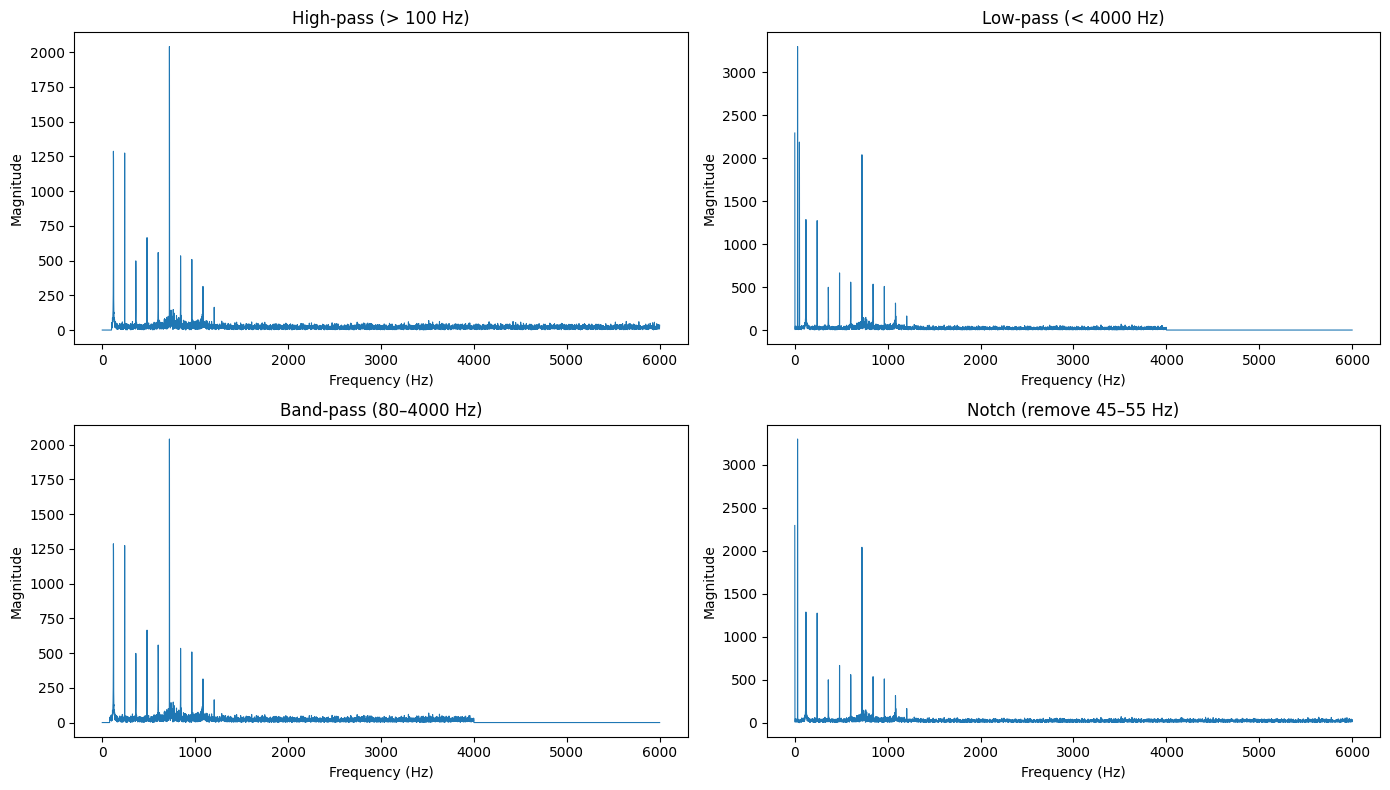

In [48]:
# Build four different masks and apply them
y_highpass = apply_mask(Y_dirty, make_mask(freqs_dirty, 'highpass', 100))
y_lowpass  = apply_mask(Y_dirty, make_mask(freqs_dirty, 'lowpass', 4000))
y_bandpass = apply_mask(Y_dirty, make_mask(freqs_dirty, 'bandpass', [80, 4000]))
y_notch    = apply_mask(Y_dirty, make_mask(freqs_dirty, 'notch', [45, 55]))

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, sig, title in zip(axes.flat,
    [y_highpass, y_lowpass, y_bandpass, y_notch],
    ['High-pass (> 100 Hz)', 'Low-pass (< 4000 Hz)',
     'Band-pass (80–4000 Hz)', 'Notch (remove 45–55 Hz)']):
    plot_spectrum(sig, sr, title, ax, max_freq=6000)

plt.tight_layout()
plt.show()


Compare the four spectra:
- **High-pass** removed the rumble (30 Hz) and hum (50 Hz), but the hiss is still there.
- **Low-pass** removed the hiss, but the rumble and hum are still there.
- **Band-pass** (80–4000 Hz) removes both rumble/hum and hiss, keeping the full voice including the fundamental at 120 Hz.
- **Notch** surgically removed just the 50 Hz hum, leaving everything else intact.

This is the power of frequency-domain filtering: you can see exactly what you're keeping and removing.

🧪 **Experiment:**
- Try a narrower band-pass of `[300, 3400]` (the telephone band) — can you hear that the voice loses its "body"? That's because the fundamental at 120 Hz is removed.
- Try `[1000, 4000]` — what happens when you remove both the fundamental and the first formant?
- Listen to each filtered signal using `Audio(signal / np.max(np.abs(signal)), rate=sr)`


In [49]:
# Listen: compare the band-pass result with the original clean speech
print("Dirty signal:")
display(Audio(y_dirty / np.max(np.abs(y_dirty)), rate=sr))
print("After band-pass filter (80–4000 Hz):")
display(Audio(y_bandpass / np.max(np.abs(y_bandpass)), rate=sr))
print("Ground truth (clean vowel):")
display(Audio(speech / np.max(np.abs(speech)), rate=sr))


Dirty signal:


After band-pass filter (80–4000 Hz):


Ground truth (clean vowel):


---
## Part 5: Real-World Application — ECG Analysis 🟡

An **electrocardiogram (ECG)** records the electrical activity of the heart. It's a perfect 1D signal for frequency analysis because:

1. The **heart rate** appears as a peak in the frequency spectrum. A heart beating at 72 beats per minute oscillates at 72/60 = 1.2 Hz.
2. Common **noise sources** have known frequencies:
   - **Baseline wander** (slow breathing drift): below 0.5 Hz → remove with high-pass
   - **Power-line hum** (50 Hz in Europe, 60 Hz in the US)
   - **Muscle noise** (patient moving): above ~45 Hz → remove with low-pass

Since the useful cardiac signal lives between about 0.5 and 45 Hz, a simple **high-pass + low-pass** combination removes both the baseline wander and the hum/noise in one go.

We'll load a real ECG from [PhysioNet](https://physionet.org/content/mitdb/), the most widely used public ECG database.


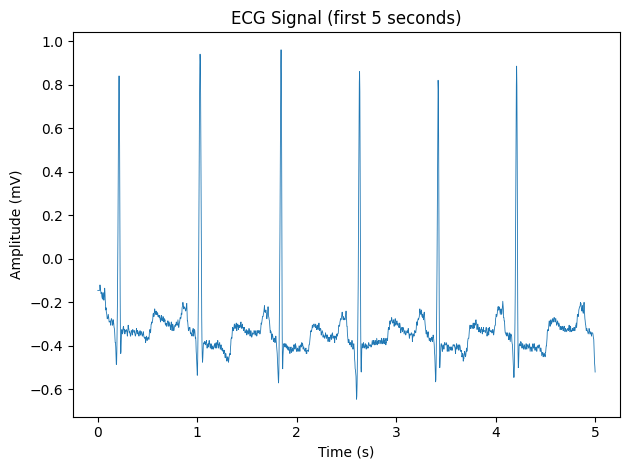

In [59]:
if WFDB:
    record = wfdb.rdrecord('100', pn_dir='mitdb')
    ecg = record.p_signal[:, 0]   # first lead
    fs  = record.fs               # sampling frequency
else:
    # Fallback: generate synthetic ECG-like signal
    print("Generating synthetic ECG-like signal...")
    fs = 360
    t_syn = np.linspace(0, 30, 30*fs, endpoint=False)
    hr = 72  # beats per minute
    ecg = np.zeros(len(t_syn))
    period = int(fs * 60 / hr)
    for i in range(len(t_syn) // period):
        idx = i * period
        if idx + 20 < len(ecg):
            ecg[idx:idx+5] = -0.2
            ecg[idx+5:idx+10] = 1.0
            ecg[idx+10:idx+15] = -0.3
            ecg[idx+15:idx+20] = 0.1
    ecg += 0.3 * np.sin(2 * np.pi * 0.15 * t_syn)   # baseline wander
    ecg += 0.05 * np.random.randn(len(ecg))           # noise

# Plot 5 seconds
t_ecg = np.arange(len(ecg)) / fs
plt.plot(t_ecg[:5*fs], ecg[:5*fs], linewidth=0.6)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (mV)')
plt.title('ECG Signal (first 5 seconds)')
plt.tight_layout()
plt.show()

You should see the characteristic repeating heartbeat pattern (the sharp spikes are called **QRS complexes**).

### Finding the heart rate from the frequency spectrum

If the heart beats at a regular rate, that repetition shows up as a peak in the frequency spectrum. A heart rate of 72 bpm corresponds to 72/60 = 1.2 Hz. Let's check.

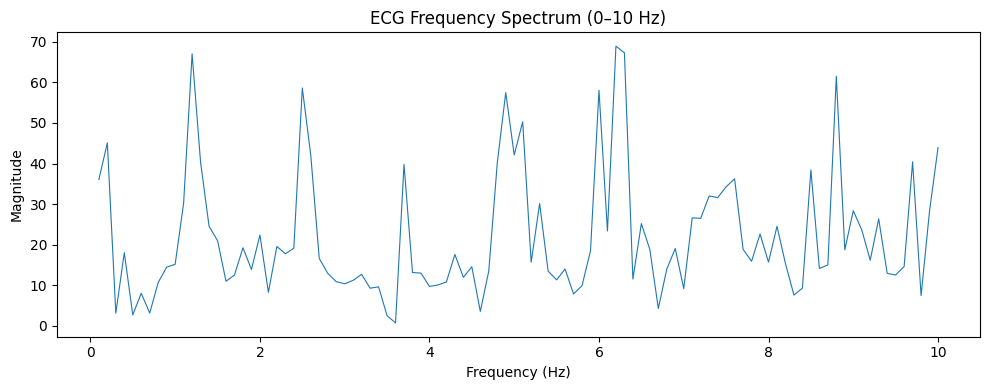

Strongest frequency in the heart-rate range: 1.20 Hz
That corresponds to 72 beats per minute


In [60]:
# Use 10 seconds for the FFT
segment = ecg[:10 * fs]

fft_vals  = np.fft.fft(segment)
magnitude = np.abs(fft_vals)
freqs     = np.fft.fftfreq(len(segment), d=1/fs)

# Plot the low-frequency part (0–10 Hz) where the heart rate lives
mask = (freqs > 0) & (freqs <= 10)
plt.figure(figsize=(10, 4))
plt.plot(freqs[mask], magnitude[mask], linewidth=0.8)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.title('ECG Frequency Spectrum (0–10 Hz)')
plt.tight_layout()
plt.show()

# Find the strongest peak between 0.5 and 3 Hz (i.e., 30 to 180 bpm)
hr_mask = (freqs >= 0.5) & (freqs <= 3.0)
peak_freq = freqs[hr_mask][np.argmax(magnitude[hr_mask])]
print(f"Strongest frequency in the heart-rate range: {peak_freq:.2f} Hz")
print(f"That corresponds to {peak_freq * 60:.0f} beats per minute")

### Cleaning the ECG with frequency masks

Since the useful cardiac signal lives between 0.5 and 45 Hz, we apply a band-pass mask — the same technique from Part 4, just with different cutoff frequencies.

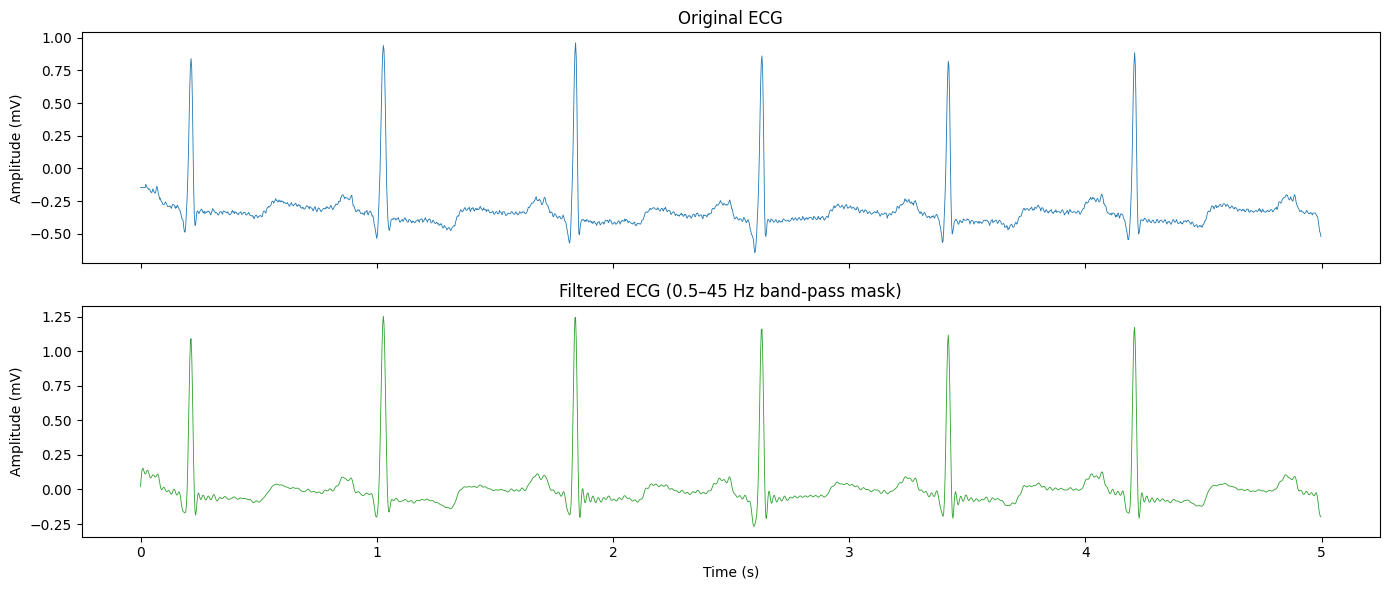

In [78]:
# FFT of the ECG segment
Y_ecg = np.fft.fft(segment)
freqs_ecg = np.fft.fftfreq(len(segment), d=1/fs)

# Band-pass mask: keep 0.5–45 Hz
mask_ecg = np.zeros(len(Y_ecg))
mask_ecg[(np.abs(freqs_ecg) >= 0.5) & (np.abs(freqs_ecg) <= 45)] = 1

ecg_clean = np.fft.ifft(Y_ecg * mask_ecg).real

# Compare
t_seg = np.arange(len(segment)) / fs
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(t_seg[:5*fs], segment[:5*fs], linewidth=0.6)
axes[0].set_title('Original ECG')
axes[0].set_ylabel('Amplitude (mV)')

axes[1].plot(t_seg[:5*fs], ecg_clean[:5*fs], linewidth=0.6, color='C2')
axes[1].set_title('Filtered ECG (0.5–45 Hz band-pass mask)')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Amplitude (mV)')

plt.tight_layout()
plt.show()

The filtered signal should look cleaner: the slow drift (baseline wander) is gone, and the high-frequency fuzz is reduced, while the QRS complexes are preserved.

🧪 **Experiment:**
- Lower the upper cutoff from 45 to 20 Hz. What happens to the sharp QRS peaks? (They need frequencies up to ~40 Hz to look sharp.)
- Try keeping only 1–10 Hz — you should see a smooth wave at the heart rate, with all the sharp features gone.
- Plot the spectrum of `ecg_clean` and verify that only the 0.5–45 Hz range has energy.

---
## Part 6: Audio Features for ML 🔴

*This section requires `librosa`. It introduces representations commonly used as inputs to machine learning models for audio tasks (speech recognition, music classification, etc.).*

### Mel Spectrograms

Human hearing is not linear: we are much better at telling apart low-frequency sounds (200 vs 400 Hz) than high-frequency sounds (8000 vs 8200 Hz). The **Mel scale** warps the frequency axis to match human perception — approximately linear below 1 kHz and logarithmic above.

A **Mel spectrogram** is simply a regular spectrogram with the frequency axis converted to the Mel scale and grouped into a fixed number of bands (typically 128). It is the standard input representation for most audio ML models.

### MFCCs — Mel-Frequency Cepstral Coefficients

MFCCs compress the Mel spectrogram into a very small number of values per frame (typically 13). The pipeline has four stages:

1. **Mel spectrogram** (128 bands): groups frequencies to match how our ears perceive them.
2. **Logarithm**: compresses the huge dynamic range of audio (whisper to shout) and mimics how we perceive loudness on a roughly logarithmic scale.
3. **Discrete Cosine Transform (DCT)**: the Mel bands are correlated (if band 5 has energy, band 6 probably does too). The DCT decorrelates them — like PCA for spectral data — concentrating important information into the first few coefficients.
4. **Keep the first ~13 coefficients**: these capture the broad *shape* of the spectrum:
   - MFCC 0: overall energy (loudness)
   - MFCCs 1–4: broad spectral shape (low vs high frequency energy)
   - MFCCs 5–13: finer details (e.g., formant positions that distinguish vowels)

This gives roughly 10× compression per frame (128 → 13) while retaining enough information to distinguish speech sounds, instruments, or speakers.

Let's compare these representations on two very different signals.


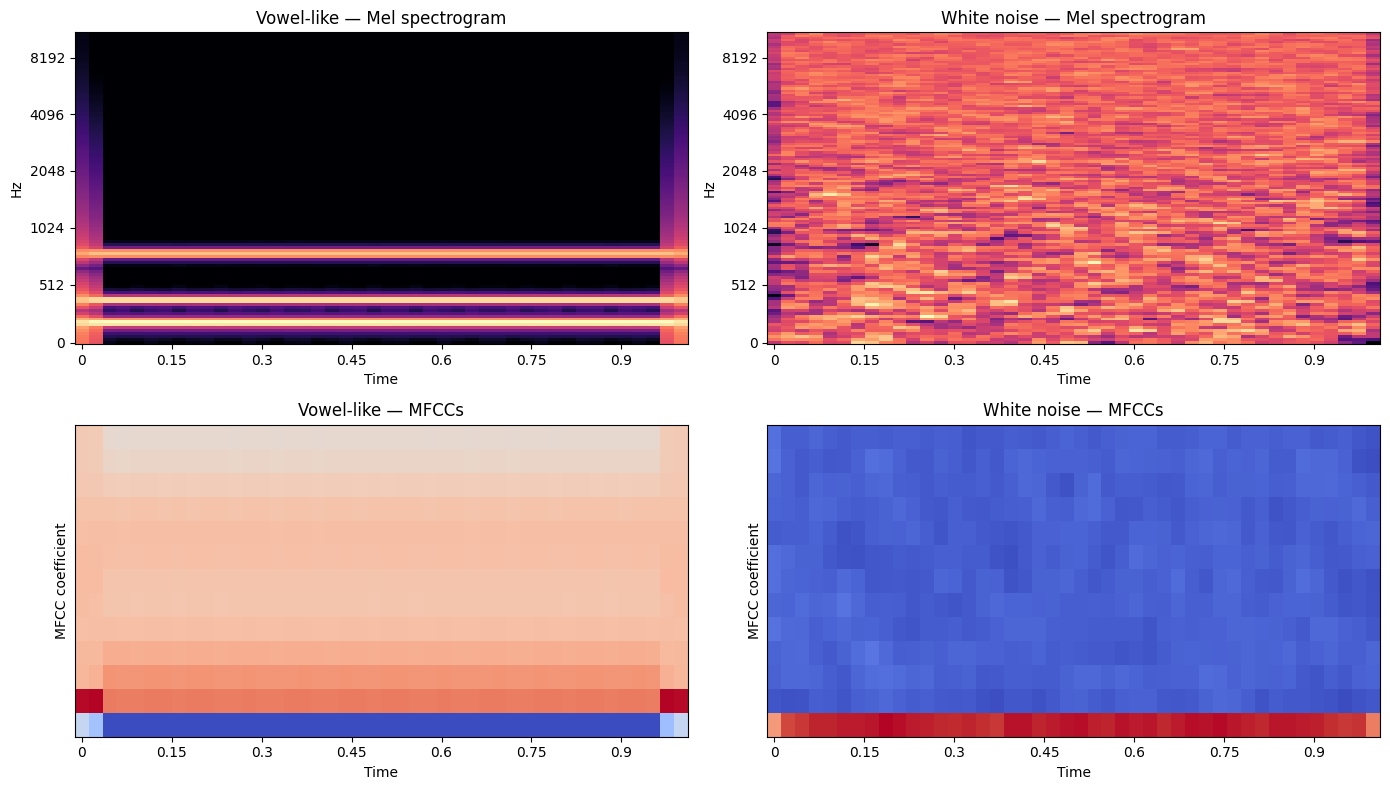

In [57]:
if LIBROSA:
    t_ml = np.linspace(0, 1.0, sr, endpoint=False)

    # Signal 1: vowel-like (fundamental + harmonics)
    y_vowel = (np.sin(2 * np.pi * 200 * t_ml) +
               0.6 * np.sin(2 * np.pi * 400 * t_ml) +
               0.3 * np.sin(2 * np.pi * 800 * t_ml)).astype(np.float32)

    # Signal 2: white noise
    y_noise = np.random.randn(sr).astype(np.float32)

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))

    for col, (y_sig, label) in enumerate([(y_vowel, 'Vowel-like'), (y_noise, 'White noise')]):
        # Mel spectrogram
        mel = librosa.feature.melspectrogram(y=y_sig, sr=sr, n_mels=128)
        mel_db = librosa.power_to_db(mel, ref=np.max)
        librosa.display.specshow(mel_db, sr=sr, hop_length=512,
                                 x_axis='time', y_axis='mel', ax=axes[0, col])
        axes[0, col].set_title(f'{label} — Mel spectrogram')

        # MFCCs
        mfccs = librosa.feature.mfcc(y=y_sig, sr=sr, n_mfcc=13)
        librosa.display.specshow(mfccs, sr=sr, hop_length=512,
                                 x_axis='time', ax=axes[1, col])
        axes[1, col].set_title(f'{label} — MFCCs')
        axes[1, col].set_ylabel('MFCC coefficient')

    plt.tight_layout()
    plt.show()
else:
    print("This section requires librosa. Install with: pip install librosa")

Notice the difference:
- The **Mel spectrogram** has 128 frequency bands per frame — a lot of data.
- The **MFCCs** have only 13 values per frame — much more compact, but still clearly different between the two signals.

The vowel-like signal has structured MFCCs (because its spectral shape is distinctive), while white noise has roughly flat MFCCs (energy is spread evenly across all frequencies).

For many ML tasks (speaker identification, genre classification, keyword spotting), MFCCs are enough. For tasks that need more detail (speech-to-text, music generation), full Mel spectrograms are preferred.

🧪 **Experiment:**
- Change `n_mfcc` from 13 to 5 — can you still see the difference between the two signals?
- Change `n_mels` from 128 to 32 — how does the Mel spectrogram change?


---
## Summary

| Concept | What it does | Key function / tool |
|---------|-------------|--------------------|
| **FFT** | Shows which frequencies are in a signal | `np.fft.fft()` |
| **Inverse FFT** | Reconstructs the signal from its spectrum | `np.fft.ifft()` |
| **Frequency mask** | Zeros out unwanted frequencies in the spectrum | `mask * np.fft.fft(y)` |
| **Spectrogram** | Shows frequencies *over time* | `plt.specgram()` |
| **Mel spectrogram** | Spectrogram warped to human hearing | `librosa.feature.melspectrogram()` |
| **MFCCs** | Compact spectral features (13 per frame) | `librosa.feature.mfcc()` |
| **Butterworth filter** | Time-domain filter (same effect as mask, smoother) | `butter()` + `filtfilt()` |

**Key insight:** Filtering = modifying the frequency spectrum. The FFT-mask-IFFT approach is the most transparent way to understand this. Butterworth filters (via `scipy`) achieve the same result via convolution in the time domain, which is equivalent by the **convolution theorem**.
